In [1]:
from pathlib import Path

import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt

from pydosert.data.utils.dicom_utils import load_ct_series, load_structures
from pydosert.utils.plotting import overlay_mask_outline

ct_folder = Path("CPPP-IMRT/CT")
rtstruct_path = "CPPP-IMRT/RS.CPPP.PHANTOM.dcm"

# ROI display colours straight from the RTSTRUCT
_rs = pydicom.dcmread(rtstruct_path)
_num_to_name = {r.ROINumber: r.ROIName for r in _rs.StructureSetROISequence}
roi_colors = {
    _num_to_name[c.ReferencedROINumber]: tuple(v / 255 for v in c.ROIDisplayColor)
    for c in _rs.ROIContourSequence
}
print("ROIs in structure set:", roi_colors)

ROIs in structure set: {'BODY': (0.0, 1.0, 0.0), 'Center': (1.0, 0.0, 1.0), 'Avoid1': (1.0, 0.0, 0.2), 'Avoid2': (0.9019607843137255, 0.6705882352941176, 0.00784313725490196)}


---
## Refined dose model (from `IMRT-validation.ipynb`)

Same structure set, treatment plan and dose model as the *Refined model* section of
`IMRT-validation.ipynb`: pydosert 1.4.0 `tb3_test` with the in-memory modifications
M1–M7, computed on a grid aligned with the TPS dose grid (C1). The cells below are copied
from that notebook; see its modifications table for what each label means.
Restart the kernel to get stock pydosert back.

In [2]:
import dataclasses
import math
import time

import torch

import pydosert.data.loaders as _ld
from pydosert.data.beam import Beam
from pydosert.data.loaders import load_dicom
from pydosert.data import MachineConfig
from pydosert import DoseEngine
from pydosert.layers.BeamWiseConvolutionalLayer import BeamWiseConvolutionalLayer

torch.set_grad_enabled(False)
DEVICE = torch.device("cpu")
DTYPE = torch.float32

rtplan_path = "CPPP-IMRT/RP.CPPP.IMRT.dcm"
rtdose_path = "CPPP-IMRT/RD.CPPP.IMRT.dcm"


# ---- Patch registry: every global pydosert modification goes through _patch() ----------
# Originals are stored so revert_pydosert_patches() restores stock pydosert in this kernel.
_PYDOSERT_ORIGINALS = {}   # (owner, attribute) -> (original object, patch ID)


def _patch(owner, attr, replacement, patch_id):
    if (owner, attr) not in _PYDOSERT_ORIGINALS:
        _PYDOSERT_ORIGINALS[(owner, attr)] = (getattr(owner, attr), patch_id)
    setattr(owner, attr, replacement)


def list_pydosert_patches():
    """Print the pydosert objects currently replaced by this notebook."""
    if not _PYDOSERT_ORIGINALS:
        print("no pydosert patches active (stock pydosert)")
    for (owner, attr), (_, pid) in _PYDOSERT_ORIGINALS.items():
        print(f"  [{pid}] {getattr(owner, '__name__', owner)}.{attr}")


def revert_pydosert_patches():
    """Restore every patched pydosert object to its original (undoes M1 + M2)."""
    for (owner, attr), (orig, pid) in _PYDOSERT_ORIGINALS.items():
        setattr(owner, attr, orig)
        print(f"reverted [{pid}] {getattr(owner, '__name__', owner)}.{attr}")
    _PYDOSERT_ORIGINALS.clear()


# [M1] X-jaw positions per control point, recorded by the parser for M4:
#      {"<SOPInstanceUID>_<BeamNumber>": np.ndarray [CP, 2] (mm)}
PLAN_X_JAWS = {}


def fetch_plan_data_imrt(plan_path):
    """[M1] Drop-in for pydosert's fetch_plan_data: tolerates control points without
    SourceToSurfaceDistance, clips the MLC leaves to the ASYMX jaws and records the
    X-jaw positions in PLAN_X_JAWS (used by M4)."""
    ds = pydicom.dcmread(str(plan_path))
    fg = ds.FractionGroupSequence[0]
    n_frac = int(fg.NumberOfFractionsPlanned)
    metersets = {str(rb.ReferencedBeamNumber): float(rb.BeamMeterset)
                 for rb in fg.ReferencedBeamSequence if hasattr(rb, "BeamMeterset")}

    params = {}
    for beam in ds.BeamSequence:
        mu_tot = metersets.get(str(beam.BeamNumber))
        if mu_tot is None:
            continue
        gantry = coll = 0.0
        ssd = iso = None
        jaw_x = jaw_y = leaves = None
        old_mu, beams, x_jaws = 0.0, [], []
        for cp in beam.ControlPointSequence:            # later CPs only carry what changes
            if cp.get("GantryAngle") is not None:              gantry = float(cp.GantryAngle)
            if cp.get("BeamLimitingDeviceAngle") is not None:  coll = float(cp.BeamLimitingDeviceAngle)
            if cp.get("SourceToSurfaceDistance") is not None:  ssd = float(cp.SourceToSurfaceDistance)
            if cp.get("IsocenterPosition") is not None and iso is None:
                ip = cp.IsocenterPosition
                iso = (float(ip[2]), float(ip[1]), float(ip[0]))
            for s in cp.get("BeamLimitingDevicePositionSequence", []):
                p = np.array([float(v) for v in s.LeafJawPositions])
                if s.RTBeamLimitingDeviceType in ("ASYMX", "X"):   jaw_x = p
                elif s.RTBeamLimitingDeviceType in ("ASYMY", "Y"): jaw_y = p
                elif s.RTBeamLimitingDeviceType == "MLCX":
                    leaves = np.stack([p[: len(p) // 2], p[len(p) // 2:]], 1)

            mu_val = mu_tot * float(cp.CumulativeMetersetWeight)
            beams.append(Beam(
                gantry_angle=math.radians(gantry),
                collimator_angle=math.radians(coll),
                ssd=ssd,
                mu=torch.from_numpy(np.array(mu_val - old_mu)),
                leaf_positions=torch.from_numpy(np.clip(leaves, jaw_x[0], jaw_x[1])),
                jaw_positions=torch.from_numpy(jaw_y.copy()),
                field_size=(400, 400),
                sid=float(beam.SourceAxisDistance),
                iso_center=iso,
            ))
            x_jaws.append(jaw_x.copy())
            old_mu = mu_val
        if beams:
            key = f"{ds.SOPInstanceUID}_{beam.BeamNumber}"
            params[key] = (beams, n_frac)
            PLAN_X_JAWS[key] = np.stack(x_jaws)
    return params


def _fft_beamwise_conv(self, fluence_vol, kernels, chunk=256):
    """[M2] FFT equivalent of BeamWiseConvolutionalLayer.forward (grouped conv2d, padding='same')."""
    BG, D, H, W, _ = fluence_vol.shape
    kH, kW = kernels.shape[0], kernels.shape[1]
    x = fluence_vol.reshape(BG * D, H, W)
    k = kernels.permute(2, 3, 0, 1).reshape(BG * D, kH, kW).flip(-2, -1)  # conv2d is a correlation
    fh, fw = H + kH - 1, W + kW - 1
    ph, pw = (kH - 1) // 2, (kW - 1) // 2
    out = torch.empty_like(x)
    for s in range(0, BG * D, chunk):
        e = min(s + chunk, BG * D)
        y = torch.fft.irfft2(torch.fft.rfft2(x[s:e], s=(fh, fw)) * torch.fft.rfft2(k[s:e], s=(fh, fw)),
                             s=(fh, fw))
        out[s:e] = y[:, ph:ph + H, pw:pw + W]
    return out.view(BG, D, H, W, 1)


_patch(_ld, "fetch_plan_data", fetch_plan_data_imrt, "M1")
_patch(BeamWiseConvolutionalLayer, "forward", _fft_beamwise_conv, "M2")
list_pydosert_patches()

  [M1] pydosert.data.loaders.fetch_plan_data
  [M2] BeamWiseConvolutionalLayer.forward


In [3]:
# Load CT + structures + plan + reference dose onto pydosert's 2 mm dose grid
patient, beam_sequences = load_dicom(
    ct_folder,
    dose_path=[rtdose_path],
    plan_path=[rtplan_path],
    struct_path=rtstruct_path,
    struct_names=list(roi_colors),
    device="cpu",
    dtype=DTYPE,
    crop_volume=True,
)
patient = patient.to("cpu").to(DTYPE)
control_points = beam_sequences[0].to("cpu")

# [M3] N+1 control points -> N delivery segments; keep the true segment MU (see note above).
#      Revert: delivery = control_points.to_delivery()
delivery = dataclasses.replace(control_points.to_delivery(), mus=control_points.mus[1:].clone())

# X jaws per delivery segment (mean of adjacent control points), only used by M4
_xj_cp = PLAN_X_JAWS[next(iter(PLAN_X_JAWS))]
xjaw_delivery = torch.from_numpy((_xj_cp[:-1] + _xj_cp[1:]) / 2).to(DTYPE)       # [N, 2] mm

dose_masks = patient.structures                 # {name: bool tensor [D, H, W]} on the dose grid
n_fx = patient.number_of_fractions
res = tuple(patient.resolution)

# CT is a placeholder (all air) -> RTSTRUCT density override: BODY = 1.0034, else air
body_red = next(float(p.ROIPhysicalPropertyValue)
                for o in _rs.RTROIObservationsSequence
                if _num_to_name[o.ReferencedROINumber] == "BODY"
                for p in o.get("ROIPhysicalPropertiesSequence", []))
density = torch.where(dose_masks["BODY"], body_red, 0.0012).to(DTYPE)

# isocentre voxel (iso_center is (z, y, x) mm relative to the grid origin)
iso_idx = tuple(int(round(c / r)) for c, r in zip(control_points.iso_center, res))

print("dose grid (D, H, W):", tuple(density.shape), " voxel (mm):", res, " fractions:", n_fx)
print(f"BODY density override: {body_red:.4f}   isocentre voxel (z, y, x): {iso_idx}")
g = delivery.gantry_angles_deg
print(f"{len(delivery)} delivery segments, gantry {float(g[0]):.0f} -> {float(g[-1]):.0f} deg, "
      f"total MU = {float(delivery.mus.sum()):.1f}")

dose grid (D, H, W): (104, 150, 150)  voxel (mm): (2.0, 2.0, 2.0)  fractions: 25
BODY density override: 1.0034   isocentre voxel (z, y, x): (51, 75, 75)
179 delivery segments, gantry 182 -> 178 deg, total MU = 665.3


In [4]:
# ---- Correction switches ---------------------------------------------------------------
APPLY_M4 = True    # [M4] X jaws in the fluence model      (False -> stock FluenceMapLayer)
DLG_MM = 1.0       # [M5] dosimetric leaf gap in mm         (None  -> stock tb3_test, no DLG)
# -----------------------------------------------------------------------------------------
import contextlib

from pydosert.layers.FluenceMapLayer import FluenceMapLayer
from pydosert.geometry.projections import fractional_box_overlap, resample_fluence_map
from pydosert.physics.fluence.fluence_modeling import (
    apply_directional_precomputed_kernel, apply_head_scatter_kernels,
    compute_sc_output_factor, estimate_field_size_1d, get_output_factor,
)

_M4_STATE = {"x_jaws": None,         # [G, 2] X-jaw positions (mm) of the beam sequence being computed
             "close_gap_mm": None}   # [M6] leaf pairs with a gap below this are treated as closed


def _fluence_forward_xjaw(self, leaf_positions, jaw_positions=None):
    """[M4] Copy of pydosert 1.4.0 FluenceMapLayer.forward, plus X jaws.
    Only the blocks marked [M4] (and the optional [M6] block) differ from the stock code."""
    B, G, N, _ = leaf_positions.shape
    leaf_positions = leaf_positions.reshape(B * G, N, 2)
    left_positions, right_positions = leaf_positions[..., 0], leaf_positions[..., 1]

    # [M6] (optional, off unless close_gap_mm is set) near-closed leaf pairs keep their planned gap
    #      but get no DLG widening (stock: every pair is widened by the DLG, see below)
    close_gap = _M4_STATE["close_gap_mm"]
    near_closed = ((right_positions - left_positions) < close_gap) if close_gap else None

    # [M4] X-jaw positions per beam: from the plan if registered, otherwise the outermost
    #      open leaves (the auto-calibration beam: leaves at +-50 mm -> 10 x 10 field)
    x_jaws = _M4_STATE["x_jaws"]
    if x_jaws is not None and x_jaws.shape[0] == B * G:
        x1, x2 = x_jaws[:, 0].to(self.dtype), x_jaws[:, 1].to(self.dtype)
    else:
        is_open = (right_positions - left_positions) > 0
        x1 = torch.where(is_open, left_positions, torch.full_like(left_positions, float("inf"))).min(1).values
        x2 = torch.where(is_open, right_positions, torch.full_like(right_positions, float("-inf"))).max(1).values
        x1, x2 = torch.nan_to_num(x1, posinf=0.0), torch.nan_to_num(x2, neginf=0.0)

    if self.dlg_half_mm > 0.0:
        dlg_half = torch.full_like(left_positions, self.dlg_half_mm)
        if near_closed is not None:                                              # [M6]
            dlg_half = torch.where(near_closed, torch.zeros_like(dlg_half), dlg_half)
        left_positions = left_positions - dlg_half
        right_positions = right_positions + dlg_half

    W = self.field_size[1]
    left_positions = left_positions.unsqueeze(1).repeat(1, W, 1)
    right_positions = right_positions.unsqueeze(1).repeat(1, W, 1)
    d = self.depth_indices.to(leaf_positions.device)

    mask = fractional_box_overlap(d, left_positions, right_positions,
                                  min_value=self.mlc_transmission, pixel_size=self.pixel_size_mm)
    mask = mask.view(B * G, W, N, 1)
    mask = resample_fluence_map(mask, self.leaf_widths, self.field_size[0], self.dtype)  # [BG, W, H, 1]

    # [M4] X-jaw aperture along W (leaf-motion axis): blocks the MLC transmission outside the jaws
    c = d[0, :, 0].view(1, W)                                   # pixel centres (mm)
    half = self.pixel_size_mm / 2
    x_open = ((torch.minimum(c + half, x2.view(-1, 1)) - torch.maximum(c - half, x1.view(-1, 1)))
              / self.pixel_size_mm).clamp(0, 1)                 # [BG, W]
    mask = mask * x_open.view(B * G, W, 1, 1)

    if jaw_positions is not None:
        jaw_positions = jaw_positions.reshape(B * G, 2)
        H = self.field_size[0]
        bottom = jaw_positions[:, 0].unsqueeze(1).unsqueeze(2).repeat(1, 1, H)
        top = jaw_positions[:, 1].unsqueeze(1).unsqueeze(2).repeat(1, 1, H)
        jaw_mask = fractional_box_overlap(self.jaw_indices.to(leaf_positions.device), bottom, top,
                                          pixel_size=self.pixel_size_mm)
        mask = mask * jaw_mask.view(B * G, 1, H, 1).repeat(1, W, 1, 1)

    aperture = mask.permute(0, 3, 2, 1)

    # [M4] OF / Sc field sizes from the actual jaw openings (stock: both read as 400 mm)
    field_size_x_mm = (x2 - x1).clamp(min=0)
    if jaw_positions is not None:
        field_size_y_mm = (jaw_positions[:, 1] - jaw_positions[:, 0]).to(self.dtype).clamp(min=0)
    else:
        field_size_y_mm = estimate_field_size_1d(aperture.mean(dim=3).squeeze(1), self.pixel_size_mm)

    # ---- unchanged stock physics pipeline -------------------------------------------------
    if self.use_penumbra:
        primary = apply_directional_precomputed_kernel(
            aperture, kernel_mlc=self.source_penumbra_kernel_mlc,
            kernel_jaw=self.source_penumbra_kernel_jaw, padding_mode="replicate").to(self.dtype)
    else:
        primary = aperture
    if self.use_profile_correction:
        primary = primary * self.profile_correction_map
    if self.use_head_scatter:
        scatter = apply_head_scatter_kernels(aperture, self.head_scatter_kernel_mlc,
                                             self.head_scatter_kernel_jaw).to(self.dtype)
        w = self.head_scatter_amplitude_mlc
        fluence_map = (1.0 - w) * primary + w * scatter
    else:
        fluence_map = primary
    if self.use_sc_model:
        sc = compute_sc_output_factor(jaw_w_mm=field_size_x_mm, jaw_h_mm=field_size_y_mm,
                                      sc_amplitude=self.sc_amplitude,
                                      sigma_x_mm=self.sc_sigma_x_mm, sigma_y_mm=self.sc_sigma_y_mm)
        fluence_map = sc[:, None, None, None] * fluence_map
    if self.use_output_factor:
        OF = get_output_factor(field_size_x_mm, field_size_y_mm, self.output_factors)
        fluence_map = OF[:, None, None, None] * fluence_map
    return fluence_map[:, 0, :, :]


@contextlib.contextmanager
def xjaw_fluence_model(x_jaws, enabled=True, close_gap_mm=None):
    """[M4] Temporarily swap in the X-jaw fluence model; the stock forward is always restored.
    close_gap_mm enables [M6] (no DLG widening for leaf pairs with a smaller gap); None = off."""
    if not enabled:
        yield
        return
    original = FluenceMapLayer.forward
    FluenceMapLayer.forward = _fluence_forward_xjaw
    _M4_STATE["x_jaws"] = x_jaws
    _M4_STATE["close_gap_mm"] = close_gap_mm
    try:
        yield
    finally:
        FluenceMapLayer.forward = original
        _M4_STATE["x_jaws"] = None
        _M4_STATE["close_gap_mm"] = None


print(f"M4 (X jaws) {'ON' if APPLY_M4 else 'OFF'}   M5 DLG = {DLG_MM} mm   "
      f"X jaws in plan: {float(xjaw_delivery[:, 0].min()):+.0f} / {float(xjaw_delivery[:, 1].max()):+.0f} mm")

M4 (X jaws) ON   M5 DLG = 1.0 mm   X jaws in plan: -29 / +29 mm


In [5]:
# [C1] pydosert grid aligned with the TPS dose grid, extended to cover the whole phantom
from pydosert.data.utils.dicom_utils import load_ct_series, load_structures

_rd = pydicom.dcmread(rtdose_path)
_b = pydicom.dcmread(rtplan_path).BeamSequence[0]
tps = _rd.pixel_array.astype(np.float64) * float(_rd.DoseGridScaling)          # (z, y, x), Gy, full course
res_rd = (float(_rd.GridFrameOffsetVector[1]) - float(_rd.GridFrameOffsetVector[0]),
          float(_rd.PixelSpacing[0]), float(_rd.PixelSpacing[1]))                 # (z, y, x) mm
origin_rd = np.array(_rd.ImagePositionPatient, float)[::-1]                        # (z, y, x) mm
PAD = np.array([1, 25, 25])        # voxels added on each side so the grid holds the whole phantom
origin_ext = origin_rd - PAD * np.array(res_rd)
shape_ext = tuple(int(n) for n in np.array(tps.shape) + 2 * PAD)
crop = tuple(slice(int(p), int(p + n)) for p, n in zip(PAD, tps.shape))       # extended grid -> TPS grid

# structures: fine CT-grid masks -> fractional occupancy on the TPS grid (5 x 5 in-plane supersampling)
_ct_img, _ = load_ct_series(ct_folder)
_fine = load_structures(_ct_img, ct_folder, rtstruct_path, struct_names=list(roi_colors))
SS = 5
_sup = sitk.Image([shape_ext[2] * SS, shape_ext[1] * SS, shape_ext[0]], sitk.sitkFloat32)
_sup.SetSpacing((res_rd[2] / SS, res_rd[1] / SS, res_rd[0]))
_sup.SetOrigin((origin_ext[2] - res_rd[2] / 2 + res_rd[2] / SS / 2,
                origin_ext[1] - res_rd[1] / 2 + res_rd[1] / SS / 2, origin_ext[0]))
masks_ext = {}
for name, img in _fine.items():
    a = sitk.GetArrayFromImage(sitk.Resample(img, _sup, sitk.Transform(), sitk.sitkNearestNeighbor, 0.0, sitk.sitkFloat32))
    masks_ext[name] = a.reshape(shape_ext[0], shape_ext[1], SS, shape_ext[2], SS).mean(axis=(2, 4)) >= 0.5
masks_rd = {name: m[crop] for name, m in masks_ext.items()}

density_rd = torch.from_numpy(np.where(masks_ext["BODY"], body_red, 0.0012)).to(DTYPE)
_iso_dicom = np.array([float(v) for v in _b.ControlPointSequence[0].IsocenterPosition])[::-1]   # (z, y, x)
delivery_rd = dataclasses.replace(delivery, iso_center=tuple(_iso_dicom - origin_ext))

print(f"TPS grid {tps.shape} @ {res_rd} mm; extended calc grid {shape_ext}")
print("voxels on the TPS grid:", {k: int(m.sum()) for k, m in masks_rd.items()},
      "  (CT grid:", {k: int(m.sum()) for k, m in dose_masks.items()}, ")")

TPS grid (81, 101, 101) @ (2.5, 2.0, 2.0) mm; extended calc grid (83, 151, 151)
voxels on the TPS grid: {'BODY': 809996, 'Center': 3712, 'Avoid1': 1138, 'Avoid2': 20}   (CT grid: {'BODY': 1009503, 'Center': 4688, 'Avoid1': 1276, 'Avoid2': 28} )


In [6]:
# ---- Refinement switches ---------------------------------------------------------------
CLOSE_GAP_MM = 1.5   # [M6] no DLG for leaf pairs with gap < this   (None -> off)
PEN_MLC_MM = 2.0     # [M7] leaf-end source penumbra FWHM (mm)       (None -> stock 1.1775)
# -----------------------------------------------------------------------------------------
_pen_stock = list(MachineConfig(preset="tb3_test").penumbra_fwhm)       # [MLC, jaw] = [1.1775, 1.1775]


def dose_on_tps_grid(close_gap_mm=None, pen_mlc_mm=None):
    """Full-course dose on the TPS grid: M4 + M5, plus optional M6 / M7."""
    pen = [pen_mlc_mm if pen_mlc_mm is not None else _pen_stock[0], _pen_stock[1]]
    mc = MachineConfig(preset="tb3_test", dlg_mm=DLG_MM, penumbra_fwhm=pen)                     # [M5] [M7]
    with xjaw_fluence_model(xjaw_delivery, enabled=APPLY_M4, close_gap_mm=close_gap_mm):        # [M4] [M6]
        eng = DoseEngine(machine_config=mc, kernel_size=151, dose_grid_spacing=res_rd,
                         dose_grid_shape=shape_ext, device=DEVICE, dtype=DTYPE, auto_calibrate=True)
        d = eng.compute_dose(delivery_rd, density_image=density_rd).squeeze(0).cpu().numpy()
    return d[crop] * n_fx


t0 = time.time()
dr_rd = dose_on_tps_grid(close_gap_mm=CLOSE_GAP_MM, pen_mlc_mm=PEN_MLC_MM)   # refined (M4–M7), TPS grid
print(f"refined dose computed in {time.time() - t0:.0f} s   M6 gap < {CLOSE_GAP_MM} mm, M7 leaf-end penumbra "
      f"{PEN_MLC_MM} mm   (FluenceMapLayer.forward stock again: {FluenceMapLayer.forward.__name__ == 'forward'})")

# plane helpers through the isocentre on the TPS grid (used by the gradient plots)
iso_rd = tuple(int(round(v)) for v in (_iso_dicom - origin_rd) / np.array(res_rd))
above_rd = tps > 0.10 * tps.max()
rz, ry, rx = iso_rd
slab_aspect = res_rd[0] / res_rd[1]           # 2.5 mm slices vs 2.0 mm in-plane
planes_rd = {                                  # (slice, display aspect)
    "axial":    (lambda a: a[rz], 1.0),
    "coronal":  (lambda a: a[:, ry], slab_aspect),
    "sagittal": (lambda a: a[:, :, rx], slab_aspect),
}
print(f"refined Dmax = {dr_rd.max():.2f} Gy   TPS Dmax = {tps.max():.2f} Gy   isocentre voxel (TPS grid): {iso_rd}")

c:\Users\mross\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydosert\engine\dose_engine.py:265: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.amp.autocast(self.device.type, dtype=self.dtype):


refined dose computed in 79 s   M6 gap < 1.5 mm, M7 leaf-end penumbra 2.0 mm   (FluenceMapLayer.forward stock again: True)
refined Dmax = 64.51 Gy   TPS Dmax = 64.72 Gy   isocentre voxel (TPS grid): (40, 51, 51)


---
## Dose gradient field of the refined model

Spatial gradient ∇D of the refined dose (`dr_rd`, M4–M7) on the TPS grid, by central
differences (one-sided at the grid edges) using the true voxel spacing (2.5 / 2.0 / 2.0 mm).
Units are Gy/mm for the full course (25 fx). It is kept in memory as `grad_rd` and
`grad_mag_rd` and saved to `IMRT-refined-dose-gradient.npz`, together with the dose, spacing
and origin so the file can be used on its own.

saved C:\dev\CPP\IMRT-refined-dose-gradient.npz   grad (3, 81, 101, 101)  (14.3 MB)
load with: g = np.load(GRAD_PATH); g['grad'], g['magnitude'], ...

ROI       mean |∇D|   95th %     max   (Gy/mm)
BODY           0.23     1.09    9.40
Center         1.12     2.63    9.26
Avoid1         2.55     4.53    5.44
Avoid2         6.07     9.27    9.40


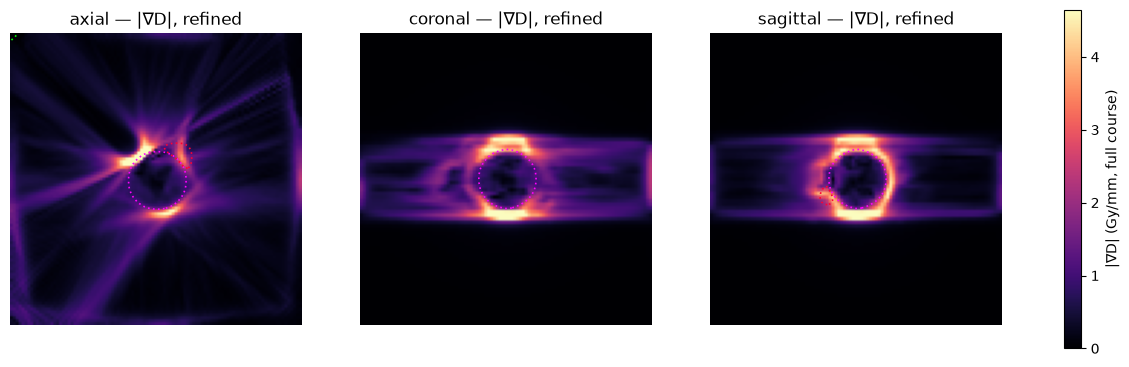

In [7]:
# Dose gradient field of the refined model on the TPS grid
grad_rd = np.stack(np.gradient(dr_rd, *res_rd), axis=0).astype(np.float32)   # [3, z, y, x]: dD/dz, dD/dy, dD/dx
grad_mag_rd = np.linalg.norm(grad_rd, axis=0)                                  # |∇D|, Gy/mm

GRAD_PATH = Path("IMRT-refined-dose-gradient.npz")
np.savez_compressed(
    GRAD_PATH,
    grad=grad_rd,                                   # [3, z, y, x] Gy/mm, components in (z, y, x) order
    magnitude=grad_mag_rd,                          # [z, y, x] Gy/mm
    dose=dr_rd.astype(np.float32),                  # [z, y, x] Gy, full course
    spacing_zyx_mm=np.array(res_rd),
    origin_zyx_mm=origin_rd,                        # DICOM patient coordinates of voxel [0, 0, 0]
    units="Gy/mm, full course",
    model="pydosert tb3_test, refined (M4-M7), TPS grid",
)
print(f"saved {GRAD_PATH.resolve()}   grad {grad_rd.shape}  "
      f"({GRAD_PATH.stat().st_size / 1e6:.1f} MB)")
print("load with: g = np.load(GRAD_PATH); g['grad'], g['magnitude'], ...")

print(f"\n{'ROI':8s} {'mean |∇D|':>10s} {'95th %':>8s} {'max':>7s}   (Gy/mm)")
for name, mk in masks_rd.items():
    v = grad_mag_rd[mk]
    print(f"{name:8s} {v.mean():10.2f} {np.percentile(v, 95):8.2f} {v.max():7.2f}")

# |∇D| through the isocentre (same planes / aspect as the refined − TPS plot above)
gmax = float(np.percentile(grad_mag_rd[above_rd], 99.5))
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (title, (slc, asp)) in zip(axes, planes_rd.items()):
    im = ax.imshow(slc(grad_mag_rd), cmap="magma", vmin=0, vmax=gmax, aspect=asp)
    ax.set_title(f"{title} — |∇D|, refined")
    plt.sca(ax)
    for name, mk in masks_rd.items():
        s = slc(mk)
        if s.any():
            overlay_mask_outline(s, color=roi_colors[name], linewidth=1.2)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="|∇D| (Gy/mm, full course)")
plt.show()

---
## Treatment plan control points

Read directly from `RP.CPPP.IMRT.dcm`. Later control points only store what changes, so
values are carried forward from the previous control point (the jaws are only stored at
CP 0). ΔMU is the MU delivered between the previous control point and this one. A leaf
pair counts as open if it lies inside the Y jaws and its gap is wider than 0.5 mm, the gap
at which this plan parks closed pairs (`CLOSED_GAP_MM`).

Beam 1 'Field 1' (DYNAMIC), 180 control points, 665.3 MU, CW

 CP gantry  coll  cum wt  cum MU    ΔMU     X1     X2     Y1     Y2 open mean gap min gap
  0  181.0   0.0  0.0000    0.00   0.00  -29.0  +29.0  -27.0  +27.0   11     23.4    15.0
  1  183.0   0.0  0.0041    2.74   2.74  -29.0  +29.0  -27.0  +27.0   11     23.5    11.2
  2  185.0   0.0  0.0082    5.47   2.74  -29.0  +29.0  -27.0  +27.0   11     20.0     6.4
  3  187.0   0.0  0.0123    8.21   2.74  -29.0  +29.0  -27.0  +27.0   10     17.7     1.2
  4  189.0   0.0  0.0161   10.68   2.48  -29.0  +29.0  -27.0  +27.0   11     18.6     4.1
  5  191.0   0.0  0.0197   13.12   2.44  -29.0  +29.0  -27.0  +27.0   10     18.8     2.9
  6  193.0   0.0  0.0234   15.55   2.44  -29.0  +29.0  -27.0  +27.0   11     16.4     5.2
  7  195.0   0.0  0.0270   17.99   2.44  -29.0  +29.0  -27.0  +27.0   11     18.3     6.1
  8  197.0   0.0  0.0307   20.42   2.44  -29.0  +29.0  -27.0  +27.0   11     16.1     6.0
  9  199.0   0.0  0.0350   23.25   2.8

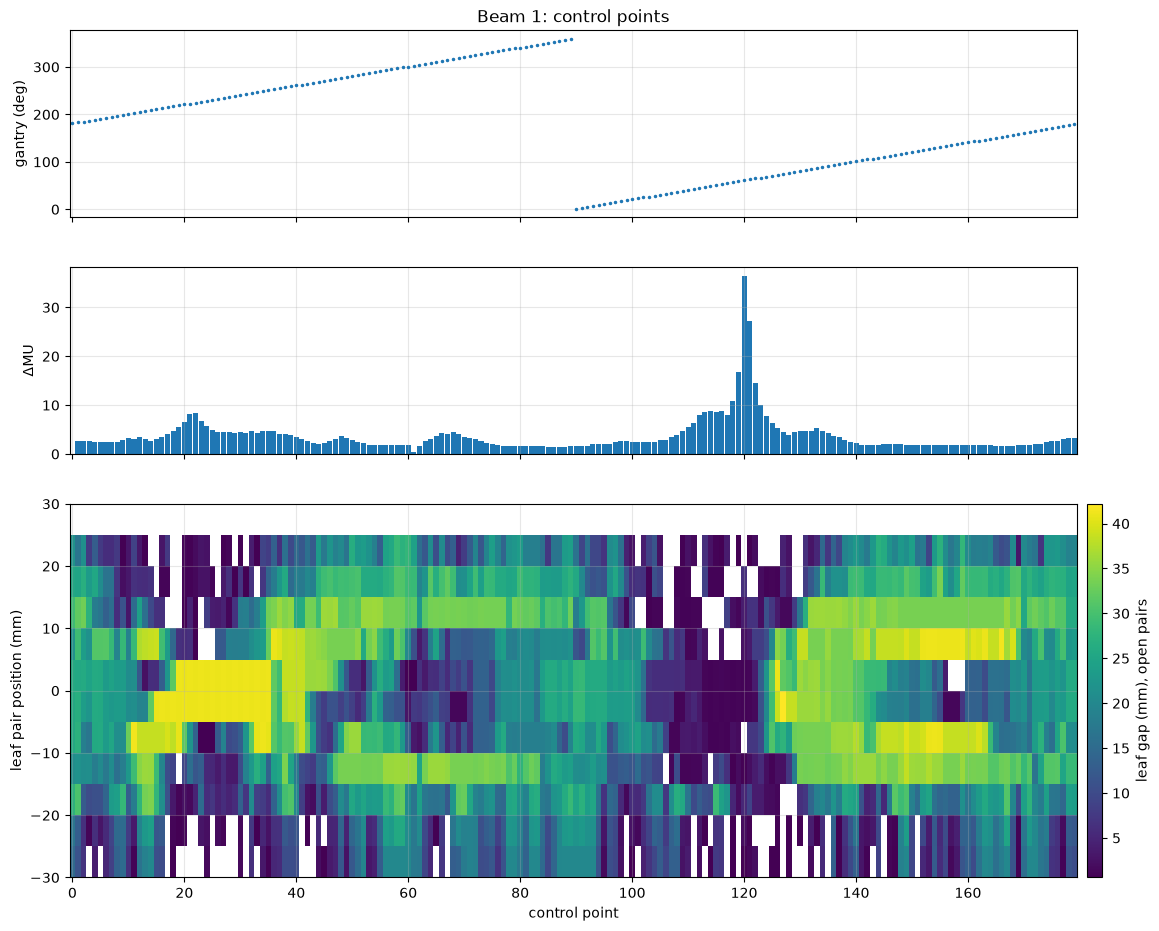

In [8]:
# Control points of the treatment plan, straight from the RTPLAN
CLOSED_GAP_MM = 0.5     # parked leaf pairs sit 0.5 mm apart in this plan: count only wider gaps as open
_plan = pydicom.dcmread(rtplan_path)
_fg = _plan.FractionGroupSequence[0]
plan_cps = {}                                             # BeamNumber -> per-CP arrays
for _beam in _plan.BeamSequence:
    _mu_beam = next(float(rb.BeamMeterset) for rb in _fg.ReferencedBeamSequence
                    if rb.ReferencedBeamNumber == _beam.BeamNumber)
    _mlc_dev = next(d for d in _beam.BeamLimitingDeviceSequence if d.RTBeamLimitingDeviceType == "MLCX")
    _bounds = np.array([float(v) for v in _mlc_dev.LeafPositionBoundaries])
    _n_pairs = len(_bounds) - 1

    gantry = coll = jaw_x = jaw_y = leaves = None
    rows = {k: [] for k in ("gantry", "coll", "weight", "jaw_x", "jaw_y", "leaves")}
    for _c in _beam.ControlPointSequence:                 # carry forward what isn't repeated
        if _c.get("GantryAngle") is not None:             gantry = float(_c.GantryAngle)
        if _c.get("BeamLimitingDeviceAngle") is not None: coll = float(_c.BeamLimitingDeviceAngle)
        for s in _c.get("BeamLimitingDevicePositionSequence", []):
            p = np.array([float(v) for v in s.LeafJawPositions])
            if s.RTBeamLimitingDeviceType in ("ASYMX", "X"):   jaw_x = p
            elif s.RTBeamLimitingDeviceType in ("ASYMY", "Y"): jaw_y = p
            elif s.RTBeamLimitingDeviceType == "MLCX":         leaves = np.stack([p[:_n_pairs], p[_n_pairs:]], 1)
        for k, v in zip(rows, (gantry, coll, float(_c.CumulativeMetersetWeight), jaw_x, jaw_y, leaves)):
            rows[k].append(v)

    cps = {k: np.array(v) for k, v in rows.items()}
    cps["cum_mu"] = cps["weight"] * _mu_beam
    cps["delta_mu"] = np.diff(cps["cum_mu"], prepend=0.0)
    gap = cps["leaves"][..., 1] - cps["leaves"][..., 0]                         # [CP, pair] mm
    in_y = ((_bounds[1:] > cps["jaw_y"][:, :1]) & (_bounds[:-1] < cps["jaw_y"][:, 1:]))
    is_open = (gap > CLOSED_GAP_MM + 1e-6) & in_y
    cps["gap"], cps["is_open"], cps["leaf_bounds"] = gap, is_open, _bounds
    plan_cps[int(_beam.BeamNumber)] = cps

    print(f"Beam {_beam.BeamNumber} '{_beam.BeamName}' ({_beam.BeamType}), {len(cps['gantry'])} control points, "
          f"{_mu_beam:.1f} MU, {_beam.ControlPointSequence[0].get('GantryRotationDirection', '')}\n")
    print(f"{'CP':>3s} {'gantry':>6s} {'coll':>5s} {'cum wt':>7s} {'cum MU':>7s} {'ΔMU':>6s} "
          f"{'X1':>6s} {'X2':>6s} {'Y1':>6s} {'Y2':>6s} {'open':>4s} {'mean gap':>8s} {'min gap':>7s}")
    for i in range(len(cps["gantry"])):
        g_open = gap[i][is_open[i]]
        mean_g, min_g = (f"{g_open.mean():8.1f}", f"{g_open.min():7.1f}") if g_open.size else (f"{'-':>8s}", f"{'-':>7s}")
        print(f"{i:3d} {cps['gantry'][i]:6.1f} {cps['coll'][i]:5.1f} {cps['weight'][i]:7.4f} "
              f"{cps['cum_mu'][i]:7.2f} {cps['delta_mu'][i]:6.2f} "
              f"{cps['jaw_x'][i, 0]:+6.1f} {cps['jaw_x'][i, 1]:+6.1f} {cps['jaw_y'][i, 0]:+6.1f} {cps['jaw_y'][i, 1]:+6.1f} "
              f"{int(is_open[i].sum()):4d} {mean_g} {min_g}")

    # gantry, ΔMU and MLC aperture per control point
    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True,
                             gridspec_kw={"height_ratios": [1, 1, 2]})
    idx = np.arange(len(cps["gantry"]))
    axes[0].plot(idx, cps["gantry"], ".", ms=3)
    axes[0].set_ylabel("gantry (deg)")
    axes[1].bar(idx, cps["delta_mu"], width=0.9)
    axes[1].set_ylabel("ΔMU")
    y_lo, y_hi = cps["jaw_y"][:, 0].min(), cps["jaw_y"][:, 1].max()
    pair_sel = (_bounds[1:] > y_lo) & (_bounds[:-1] < y_hi)                     # pairs ever inside Y jaws
    im = axes[2].imshow(np.where(is_open, gap, np.nan)[:, pair_sel].T, aspect="auto", origin="lower",
                        cmap="viridis", interpolation="nearest",
                        extent=(-0.5, idx[-1] + 0.5, _bounds[:-1][pair_sel][0], _bounds[1:][pair_sel][-1]))
    axes[2].set_ylabel("leaf pair position (mm)")
    axes[2].set_xlabel("control point")
    fig.colorbar(im, cax=axes[2].inset_axes([1.01, 0, 0.015, 1]),     # inset: keeps the panels aligned
                 label="leaf gap (mm), open pairs")
    axes[0].set_title(f"Beam {_beam.BeamNumber}: control points")
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.show()